In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
import pandas as pd


In [2]:
import src.preference_factors.build_datasets as bd

In [4]:
from src.FamaMacBeth.betas import compute_rolling_betas
from src.FamaMacBeth.pipeline import run_full_factor_pipeline

merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

ebc = merged_df["EBC"]
cw_ebc = merged_df["CW-EBC"]


/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_weights = full_weights.fillna(0.0)


In [5]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

In [6]:
asset_returns = bd.build_returns_dataset("sp500_returns_monthly_with_tickers.csv", frequency="monthly")
factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()
factor_returns.columns = ["EBC", "CW-EBC"]

asset_returns, factor_returns = asset_returns.align(factor_returns, join="inner", axis=0)

betas_ebc = compute_rolling_betas(asset_returns, ebc, rolling_window=36, min_obs=10)
betas_cw_ebc = compute_rolling_betas(asset_returns, cw_ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 666/666 [00:05<00:00, 123.73it/s]


In [7]:
results = run_full_factor_pipeline(
    beta1_df=betas_ebc,
    beta2_df=betas_cw_ebc,
    sp500=asset_returns,
    EBC=factor_returns["EBC"],
    Cap_EBC=factor_returns["CW-EBC"],
    n_q1=3,
    n_q2=3,
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC",
    frequency = 'monthly'
)

results["mean_grid"]

forming portfolios: 100%|██████████| 666/666 [00:04<00:00, 155.45it/s]


,1,2,3
1,0.011339,0.011931,0.013640
2,0.010275,0.011256,0.012354
3,0.008863,0.010144,0.010977


In [8]:
results['portrets_wide'][:5]

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
date,,,,,,,,,
1969-07,-0.070881,-0.074579,-0.104431,-0.066566,-0.054037,-0.070431,-0.058360,-0.061391,-0.057427
1969-08,0.062950,0.059240,0.061104,0.047637,0.054932,0.024536,0.056311,0.009131,0.022849
1969-09,-0.033842,-0.016010,-0.030269,-0.013909,-0.005441,-0.007409,-0.015200,-0.015275,-0.019476
1969-10,0.053560,0.054181,0.095237,0.057391,0.068108,0.077376,0.067129,0.063560,0.054324
1969-11,-0.060631,-0.065312,-0.064773,-0.023578,-0.025080,-0.049597,-0.031084,-0.027441,-0.034057


In [9]:
from pathlib import Path
import src.FamaMacBeth.backtest as backtest
'''(
    load_monthly_inputs,
    backtest_quantile_portfolios,
    compute_excess_returns,
)
'''
import src.FamaMacBeth.plots as plots
''' (
    plot_cum_log_returns,
    plot_expected_return_grid,
)
'''
from src.FamaMacBeth.plots import plot_mean_grid

In [10]:
# ============================
# USER PARAMETERS
# ============================
start_date = "1970-01-01"
use_excess_returns = True

# ============================
# REQUIRED INPUTS FROM PIPELINE
# ============================
members_df = results["members"]
n_q1, n_q2 = results["mean_grid"].shape

# ============================
# LOAD RETURNS / CAPS / RF
# ============================
DATA_RAW_DIR = Path.cwd().parent / "data" / "raw"
sp_500, sp_caps, rf = backtest.load_monthly_inputs(DATA_RAW_DIR)

In [11]:
# ============================
# RUN BACKTEST
# ============================
quantile_portfolios_returns = backtest.backtest_quantile_portfolios(
    members_df=members_df,
    returns_df=sp_500,
    caps_df=sp_caps,
    n_q1=n_q1,
    n_q2=n_q2,
    weight="cap",
)

if use_excess_returns:
    quantile_portfolios_returns = backtest.compute_excess_returns(
        quantile_portfolios_returns, rf, start_date=start_date
    )
else:
    quantile_portfolios_returns = quantile_portfolios_returns.loc[start_date:]

In [12]:
rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}

quantile_portfolios_returns = quantile_portfolios_returns.rename(columns=rename_map)


In [13]:
full_merged_df.index = full_merged_df.index.to_timestamp(how="start")
full_merged_df.index.name = "date"


In [14]:
complete_df = full_merged_df.join(
    quantile_portfolios_returns,
    how="inner"
)


In [15]:
complete_df.columns

Index(['CW', 'EW', 'EBC', 'CW-EW', 'CW-EBC', 'MKT_RF', 'SMB', 'HML', 'RMW',
       'CMA', 'RF', 'MOM', 'EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low'],
      dtype='object')

In [16]:
selected_columns = ['CW','EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low']

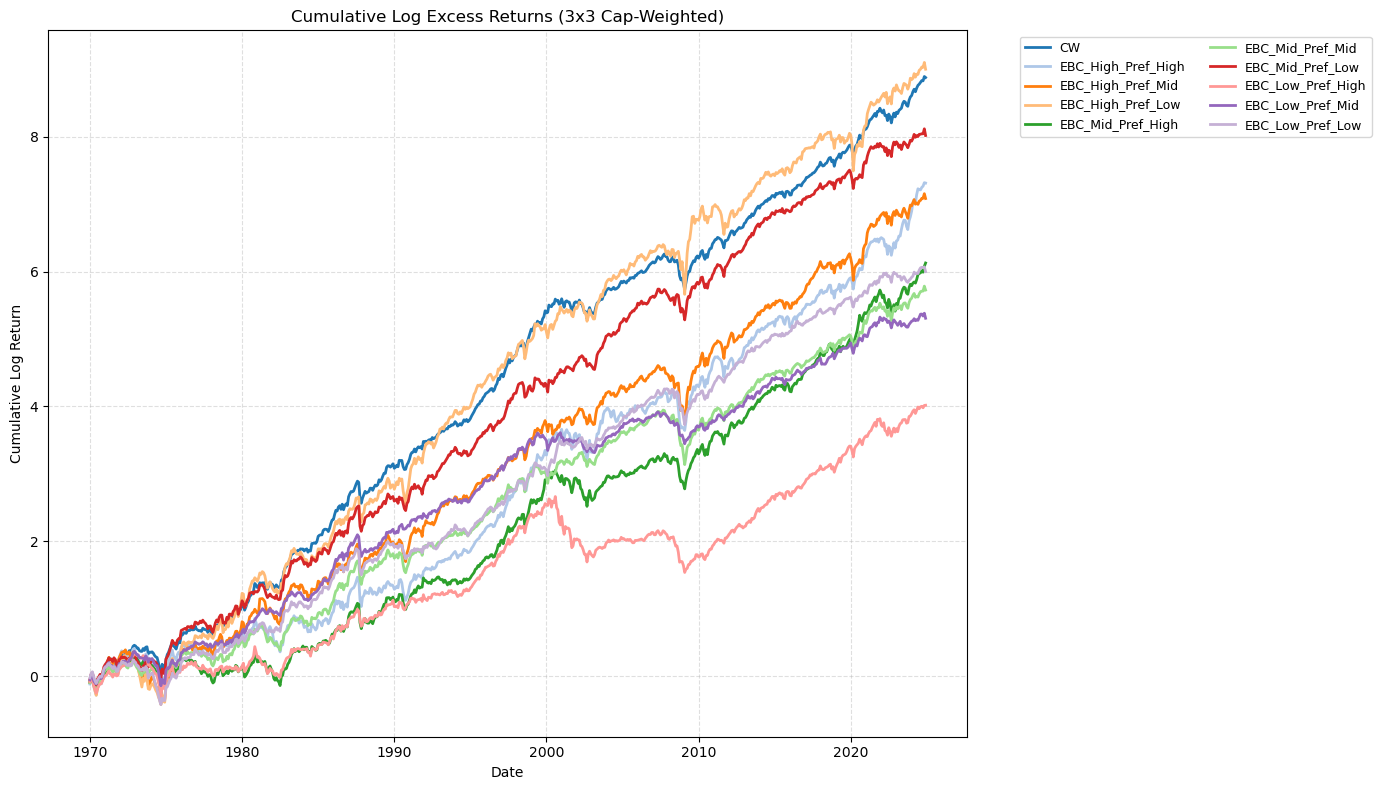

In [17]:
# ============================
# PLOTS
# ============================
plots.plot_cum_log_returns(
    complete_df[selected_columns],
    title=f"Cumulative Log Excess Returns ({n_q1}x{n_q2} Cap-Weighted)",
)

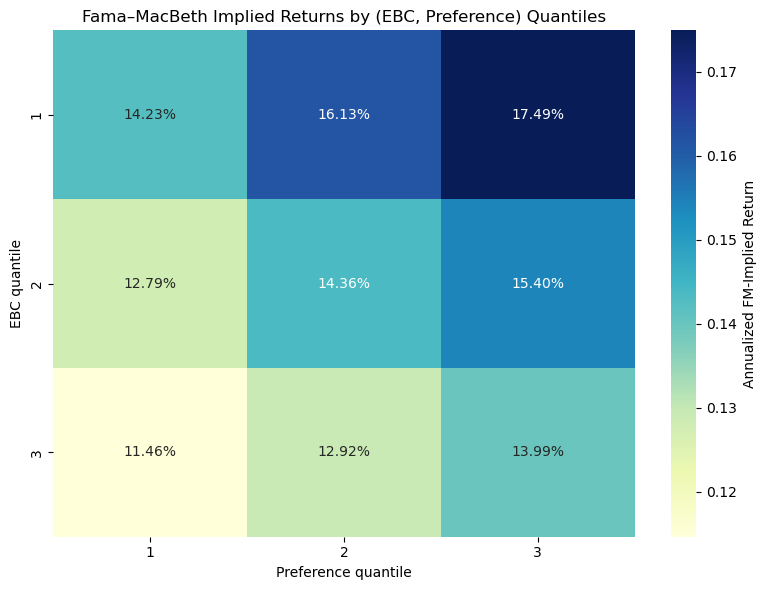

In [18]:
# FM expected-return grid (annualized %)
plots.plot_expected_return_grid(results["pricing"], results["fm_table"], n_q1, n_q2)

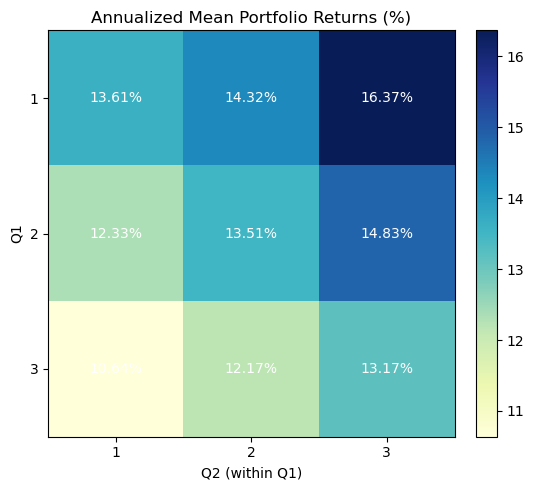

In [19]:
plot_mean_grid(results["mean_grid"], annualize=True)

In [20]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [21]:
quantile_portfolios_returns.index = (
    quantile_portfolios_returns.index.to_period("M")
)
quantile_portfolios_returns.index.name = "date"


In [22]:
quantile_portfolios_returns.to_csv(DATA_PROCESSED_DIR / "monthly_quantile_returns_3x3.csv")